# 🌶️ ChiliScope — Price Prediction Model Training

## Random Forest Regressor for Philippine Chili Price Forecasting

This notebook trains a **Random Forest Regressor** to predict chili prices (Siling Labuyo & Siling Haba) using historical market price data from `.xlsx` files in the `assets/` folder.

**Data sources:**
- `Siling Labuyo Price(3).xlsx` — Full Labuyo dataset (2024–2025) with LOW, HIGH, PREVAILING, AVERAGE
- `Siling Haba.xlsx` — Haba dataset (Sep 2025–Feb 2026) with PREVAILING prices

**Model:** `RandomForestRegressor` from scikit-learn

## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from datetime import datetime

from sklearn.model_selection import train_test_split, GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load Excel Datasets from Assets Folder

We have 4 xlsx files, but the best ones to use are:
- **`Siling Labuyo Price(3).xlsx`** — Most complete Labuyo data (~597 rows, 2024–2025)
- **`Siling Haba.xlsx`** — Haba data (141 rows, Sep 2025–Feb 2026)

The other Labuyo files are subsets of file (3), so we'll use only the largest one to avoid duplicates.

In [2]:
# --- Configuration ---
ASSETS_DIR = os.path.join(os.getcwd(), "assets")
MODEL_DIR = os.path.join(os.getcwd(), "backend", "app", "ml", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# --- Load Siling Labuyo (largest file) ---
labuyo_path = os.path.join(ASSETS_DIR, "Siling Labuyo Price(3).xlsx")
df_labuyo_raw = pd.read_excel(labuyo_path, header=None)

print(f"📁 Loaded: Siling Labuyo Price(3).xlsx — Shape: {df_labuyo_raw.shape}")
display(df_labuyo_raw.head(5))

# --- Load Siling Haba ---
haba_path = os.path.join(ASSETS_DIR, "Siling Haba.xlsx")
df_haba_raw = pd.read_excel(haba_path, header=None)

print(f"\n📁 Loaded: Siling Haba.xlsx — Shape: {df_haba_raw.shape}")
display(df_haba_raw.head(5))

📁 Loaded: Siling Labuyo Price(3).xlsx — Shape: (601, 5)


,0,1,2,3,4
0,2025,PRICE (per kg),NaN,NaN,NaN
1,NaN,LOW,HIGH,PREVAILING,AVERAGE
2,2025-01-02 00:00:00,750,900,NaN,NaN
3,2025-01-03 00:00:00,600,1000,NaN,NaN
4,2025-01-04 00:00:00,500,1000,NaN,NaN



📁 Loaded: Siling Haba.xlsx — Shape: (143, 5)


,0,1,2,3,4
0,DATE,PRICE (per kg),NaN,NaN,NaN
1,NaN,LOW,HIGH,PREVAILING,AVERAGE
2,2025-09-24 00:00:00,NaN,NaN,143.26,NaN
3,2025-09-25 00:00:00,NaN,NaN,137.76,NaN
4,2025-09-26 00:00:00,NaN,NaN,142.26,NaN


## Step 3: Clean and Parse the Raw Data

The Excel files have a 2-row header structure:
- Row 0: `DATE | PRICE (per kg) | ... `
- Row 1: `(blank) | LOW | HIGH | PREVAILING | AVERAGE`

We need to skip these headers, parse dates properly, and handle the mixed date formats (some are `datetime`, some are strings like `12/31/2025`).

In [3]:
def parse_chili_data(df_raw, chili_type, has_all_cols=True):
    """Parse raw Excel data into a clean DataFrame."""
    # Skip header rows (first 2 rows)
    df = df_raw.iloc[2:].copy()
    
    if has_all_cols and df.shape[1] >= 5:
        df.columns = ['date', 'low', 'high', 'prevailing', 'average']
    elif df.shape[1] >= 3:
        df.columns = ['date', 'low', 'high'] + [f'col_{i}' for i in range(3, df.shape[1])]
    else:
        df.columns = ['date'] + [f'col_{i}' for i in range(1, df.shape[1])]
    
    # Drop rows where date is null
    df = df.dropna(subset=['date'])
    
    # Filter out non-date values (like year-only values)
    def safe_parse_date(val):
        if isinstance(val, datetime):
            return val
        if isinstance(val, (int, float)):
            return pd.NaT
        try:
            return pd.to_datetime(val)
        except:
            return pd.NaT
    
    df['date'] = df['date'].apply(safe_parse_date)
    df = df.dropna(subset=['date'])
    
    # Convert numeric columns
    numeric_cols = [c for c in df.columns if c != 'date']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    # Add chili type
    df['chili_type'] = chili_type
    
    # Sort by date
    df = df.sort_values('date').reset_index(drop=True)
    
    return df

# Parse Labuyo data
df_labuyo = parse_chili_data(df_labuyo_raw, 'siling_labuyo', has_all_cols=True)
print(f"🌶️ Siling Labuyo: {len(df_labuyo)} records")
print(f"   Date range: {df_labuyo['date'].min().date()} → {df_labuyo['date'].max().date()}")
display(df_labuyo.head())

# Parse Haba data
df_haba = parse_chili_data(df_haba_raw, 'siling_haba', has_all_cols=True)
print(f"\n🌶️ Siling Haba: {len(df_haba)} records")
print(f"   Date range: {df_haba['date'].min().date()} → {df_haba['date'].max().date()}")
display(df_haba.head())

🌶️ Siling Labuyo: 597 records
   Date range: 2024-01-03 → 2025-12-31


,date,low,high,prevailing,average,chili_type
0,2024-01-03,190,500,NaN,NaN,siling_labuyo
1,2024-01-04,200,400,NaN,NaN,siling_labuyo
2,2024-01-05,160,350,NaN,NaN,siling_labuyo
3,2024-01-07,150,300,NaN,NaN,siling_labuyo
4,2024-01-08,170,350,NaN,NaN,siling_labuyo



🌶️ Siling Haba: 141 records
   Date range: 2025-09-24 → 2026-02-11


,date,low,high,prevailing,average,chili_type
0,2025-09-24,NaN,NaN,143.26,NaN,siling_haba
1,2025-09-25,NaN,NaN,137.76,NaN,siling_haba
2,2025-09-26,NaN,NaN,142.26,NaN,siling_haba
3,2025-09-27,NaN,NaN,139.09,NaN,siling_haba
4,2025-09-28,NaN,NaN,100.00,NaN,siling_haba


In [4]:
# --- Create a unified price column ---
# For Labuyo: compute average price from LOW and HIGH if AVERAGE column is missing
# For Haba: use PREVAILING price as the main price

def compute_price(row):
    """Get the best available price value."""
    # Try average first
    if 'average' in row.index and pd.notna(row.get('average')) and row['average'] > 0:
        return row['average']
    # Try prevailing
    if 'prevailing' in row.index and pd.notna(row.get('prevailing')) and row['prevailing'] > 0:
        return row['prevailing']
    # Compute from low/high
    low = row.get('low', np.nan)
    high = row.get('high', np.nan)
    if pd.notna(low) and pd.notna(high) and low > 0 and high > 0:
        return (low + high) / 2
    if pd.notna(low) and low > 0:
        return low
    if pd.notna(high) and high > 0:
        return high
    return np.nan

df_labuyo['price'] = df_labuyo.apply(compute_price, axis=1)
df_haba['price'] = df_haba.apply(compute_price, axis=1)

# Drop rows with no valid price
df_labuyo = df_labuyo.dropna(subset=['price'])
df_haba = df_haba.dropna(subset=['price'])

print(f"✅ Labuyo with valid prices: {len(df_labuyo)}")
print(f"✅ Haba with valid prices: {len(df_haba)}")

# Combine into one DataFrame
df_combined = pd.concat([df_labuyo, df_haba], ignore_index=True)
df_combined = df_combined.sort_values('date').reset_index(drop=True)

# Keep only useful columns
df = df_combined[['date', 'low', 'high', 'price', 'chili_type']].copy()

print(f"\n📊 Combined dataset: {len(df)} records")
display(df.describe())

✅ Labuyo with valid prices: 597
✅ Haba with valid prices: 141

📊 Combined dataset: 738 records


,date,low,high,price
count,738,597.000000,597.000000,738.000000
mean,2025-03-02 05:39:30.731707,200.410385,400.670017,287.703049
min,2024-01-03 00:00:00,50.000000,150.000000,100.000000
25%,2024-08-21 06:00:00,90.000000,250.000000,160.115000
50%,2025-03-16 00:00:00,150.000000,350.000000,242.445000
75%,2025-10-10 00:00:00,280.000000,500.000000,366.020000
max,2026-02-11 00:00:00,750.000000,1200.000000,905.000000
std,NaN,138.238404,209.011464,162.982637


## Step 4: Explore and Understand the Data

Let's visualize the price trends, distributions, and understand the data before feature engineering.

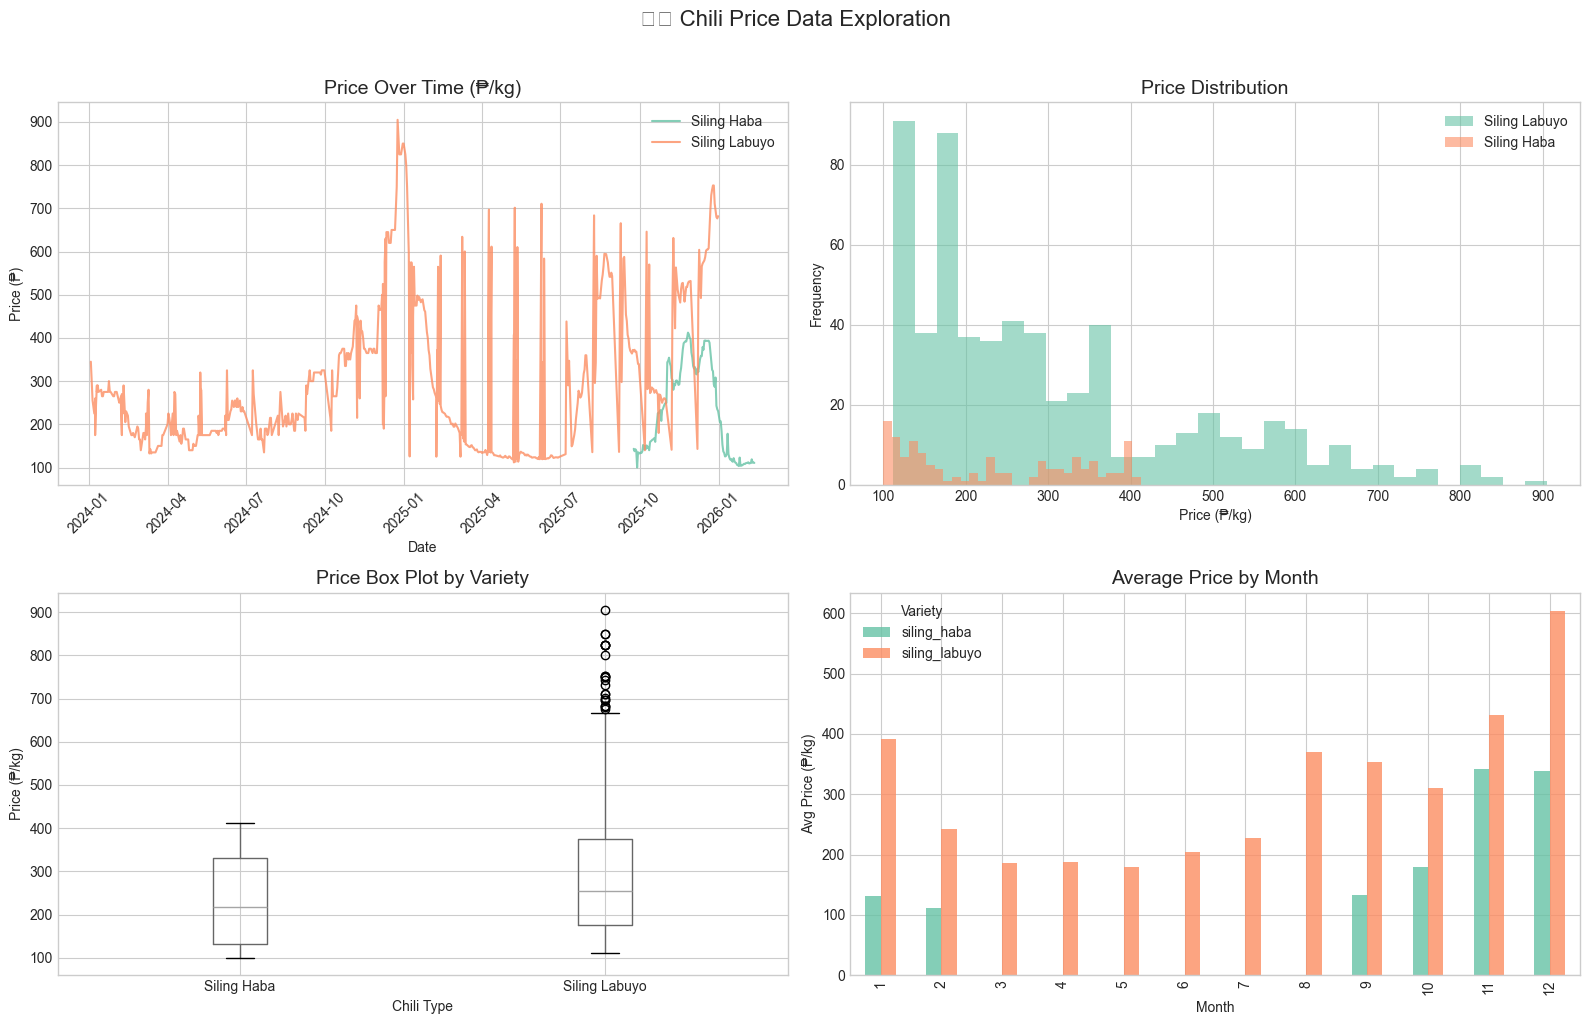


📊 Summary Statistics by Chili Type:


,count,mean,std,min,25%,50%,75%,max
chili_type,,,,,,,,
siling_haba,141.0,230.69,105.38,100.00,132.5,217.83,330.08,412.27
siling_labuyo,597.0,301.17,171.14,111.87,175.0,255.00,375.00,905.00


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Price over time by chili type
for ctype, group in df.groupby('chili_type'):
    axes[0, 0].plot(group['date'], group['price'], label=ctype.replace('_', ' ').title(), alpha=0.8)
axes[0, 0].set_title('Price Over Time (₱/kg)', fontsize=14)
axes[0, 0].set_xlabel('Date')
axes[0, 0].set_ylabel('Price (₱)')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Price distribution per chili type
for ctype in df['chili_type'].unique():
    subset = df[df['chili_type'] == ctype]['price']
    axes[0, 1].hist(subset, bins=30, alpha=0.6, label=ctype.replace('_', ' ').title())
axes[0, 1].set_title('Price Distribution', fontsize=14)
axes[0, 1].set_xlabel('Price (₱/kg)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend()

# 3. Box plot by chili type
df.boxplot(column='price', by='chili_type', ax=axes[1, 0])
axes[1, 0].set_title('Price Box Plot by Variety', fontsize=14)
axes[1, 0].set_xlabel('Chili Type')
axes[1, 0].set_ylabel('Price (₱/kg)')
plt.sca(axes[1, 0])
plt.xticks([1, 2], ['Siling Haba', 'Siling Labuyo'])

# 4. Monthly average price
df['month'] = df['date'].dt.month
monthly = df.groupby(['month', 'chili_type'])['price'].mean().unstack()
monthly.plot(kind='bar', ax=axes[1, 1], alpha=0.8)
axes[1, 1].set_title('Average Price by Month', fontsize=14)
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Avg Price (₱/kg)')
axes[1, 1].legend(title='Variety')

plt.suptitle('🌶️ Chili Price Data Exploration', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Summary stats
print("\n📊 Summary Statistics by Chili Type:")
display(df.groupby('chili_type')['price'].describe().round(2))

## Step 5: Feature Engineering

For time-series price prediction with Random Forest, we create features from the date and historical prices:

**Time features:** day of week, day of month, month, quarter, week of year, is weekend  
**Lag features:** price from 1, 3, 7, 14, 30 days ago  
**Rolling features:** 7-day and 14-day rolling mean and std  
**Price spread:** difference between high and low prices  
**Chili type:** encoded as a numeric feature

In [6]:
def engineer_features(df_input):
    """Create time-series features for each chili type separately, then combine."""
    all_frames = []
    
    for ctype in df_input['chili_type'].unique():
        df_c = df_input[df_input['chili_type'] == ctype].copy()
        df_c = df_c.sort_values('date').reset_index(drop=True)
        
        # ---- Time-based features ----
        df_c['day_of_week'] = df_c['date'].dt.dayofweek        # 0=Mon, 6=Sun
        df_c['day_of_month'] = df_c['date'].dt.day
        df_c['month'] = df_c['date'].dt.month
        df_c['quarter'] = df_c['date'].dt.quarter
        df_c['week_of_year'] = df_c['date'].dt.isocalendar().week.astype(int)
        df_c['is_weekend'] = (df_c['day_of_week'] >= 5).astype(int)
        
        # Cyclical encoding for month (captures seasonality)
        df_c['month_sin'] = np.sin(2 * np.pi * df_c['month'] / 12)
        df_c['month_cos'] = np.cos(2 * np.pi * df_c['month'] / 12)
        df_c['dow_sin'] = np.sin(2 * np.pi * df_c['day_of_week'] / 7)
        df_c['dow_cos'] = np.cos(2 * np.pi * df_c['day_of_week'] / 7)
        
        # ---- Lag features (past prices) ----
        for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
            df_c[f'price_lag_{lag}'] = df_c['price'].shift(lag)
        
        # ---- Rolling window features ----
        for window in [3, 7, 14, 30]:
            df_c[f'rolling_mean_{window}'] = df_c['price'].rolling(window=window).mean()
            df_c[f'rolling_std_{window}'] = df_c['price'].rolling(window=window).std()
            df_c[f'rolling_min_{window}'] = df_c['price'].rolling(window=window).min()
            df_c[f'rolling_max_{window}'] = df_c['price'].rolling(window=window).max()
        
        # ---- Price change features ----
        df_c['price_change_1d'] = df_c['price'].diff(1)
        df_c['price_change_7d'] = df_c['price'].diff(7)
        df_c['price_pct_change_1d'] = df_c['price'].pct_change(1)
        df_c['price_pct_change_7d'] = df_c['price'].pct_change(7)
        
        # ---- Spread features ----
        if 'low' in df_c.columns and 'high' in df_c.columns:
            df_c['price_spread'] = df_c['high'] - df_c['low']
            df_c['price_spread'] = df_c['price_spread'].fillna(0)
        else:
            df_c['price_spread'] = 0
        
        # ---- Days since start (trend) ----
        df_c['days_since_start'] = (df_c['date'] - df_c['date'].min()).dt.days
        
        all_frames.append(df_c)
    
    result = pd.concat(all_frames, ignore_index=True)
    
    # Encode chili type
    le = LabelEncoder()
    result['chili_type_encoded'] = le.fit_transform(result['chili_type'])
    
    return result, le

df_feat, chili_encoder = engineer_features(df)

print(f"📊 Feature-engineered dataset: {df_feat.shape}")
print(f"\n🔢 Features created: {df_feat.shape[1] - 5} new features")  # minus original cols
print(f"\nFeature columns:")
feature_cols = [c for c in df_feat.columns if c not in ['date', 'chili_type', 'low', 'high', 'price']]
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

📊 Feature-engineered dataset: (738, 46)

🔢 Features created: 41 new features

Feature columns:
   1. month
   2. day_of_week
   3. day_of_month
   4. quarter
   5. week_of_year
   6. is_weekend
   7. month_sin
   8. month_cos
   9. dow_sin
  10. dow_cos
  11. price_lag_1
  12. price_lag_2
  13. price_lag_3
  14. price_lag_5
  15. price_lag_7
  16. price_lag_14
  17. price_lag_21
  18. price_lag_30
  19. rolling_mean_3
  20. rolling_std_3
  21. rolling_min_3
  22. rolling_max_3
  23. rolling_mean_7
  24. rolling_std_7
  25. rolling_min_7
  26. rolling_max_7
  27. rolling_mean_14
  28. rolling_std_14
  29. rolling_min_14
  30. rolling_max_14
  31. rolling_mean_30
  32. rolling_std_30
  33. rolling_min_30
  34. rolling_max_30
  35. price_change_1d
  36. price_change_7d
  37. price_pct_change_1d
  38. price_pct_change_7d
  39. price_spread
  40. days_since_start
  41. chili_type_encoded


## Step 6: Prepare Data — Handle NaN and Split

Lag and rolling features create NaN values at the beginning of each series. We drop those rows, then split into train/test.

**Important:** For time-series data, we split chronologically (not randomly) to avoid data leakage.

In [7]:
# Define feature columns (exclude target 'price', date, chili_type string, low, high)
FEATURE_COLS = [c for c in df_feat.columns if c not in ['date', 'chili_type', 'low', 'high', 'price']]
TARGET_COL = 'price'

# Drop rows with NaN (from lag/rolling features)
df_model = df_feat.dropna(subset=FEATURE_COLS).copy()
print(f"Rows after dropping NaN: {len(df_model)} (dropped {len(df_feat) - len(df_model)} rows)")

# Replace any remaining inf values
df_model = df_model.replace([np.inf, -np.inf], np.nan)
df_model = df_model.dropna(subset=FEATURE_COLS)

# Sort by date for chronological split
df_model = df_model.sort_values('date').reset_index(drop=True)

X = df_model[FEATURE_COLS].values
y = df_model[TARGET_COL].values

# Chronological split: 80% train, 20% test
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

# Save dates for plotting later
dates_train = df_model['date'].iloc[:split_idx].values
dates_test = df_model['date'].iloc[split_idx:].values
types_test = df_model['chili_type'].iloc[split_idx:].values

print(f"\n✅ Train set: {X_train.shape[0]} samples")
print(f"✅ Test set:  {X_test.shape[0]} samples")
print(f"📋 Features:  {X_train.shape[1]}")
print(f"\n📅 Train period: {pd.Timestamp(dates_train[0]).date()} → {pd.Timestamp(dates_train[-1]).date()}")
print(f"📅 Test period:  {pd.Timestamp(dates_test[0]).date()} → {pd.Timestamp(dates_test[-1]).date()}")

Rows after dropping NaN: 678 (dropped 60 rows)

✅ Train set: 542 samples
✅ Test set:  136 samples
📋 Features:  41

📅 Train period: 2024-02-08 → 2025-11-07
📅 Test period:  2025-11-08 → 2026-02-11


## Step 7: Train Baseline Random Forest Model

First, let's train a baseline model with default hyperparameters to see how well it performs.

In [8]:
import time

# --- Baseline Random Forest ---
print("🌲 Training baseline Random Forest...")
start = time.time()

rf_baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,  # Use all CPU cores
)
rf_baseline.fit(X_train, y_train)

elapsed = time.time() - start
print(f"⏱️ Training time: {elapsed:.2f}s")

# Evaluate baseline
y_pred_train = rf_baseline.predict(X_train)
y_pred_test = rf_baseline.predict(X_test)

print(f"\n📊 Baseline Results:")
print(f"{'Metric':<20} {'Train':>12} {'Test':>12}")
print(f"{'─'*44}")
print(f"{'MAE (₱)':<20} {mean_absolute_error(y_train, y_pred_train):>12.2f} {mean_absolute_error(y_test, y_pred_test):>12.2f}")
print(f"{'RMSE (₱)':<20} {np.sqrt(mean_squared_error(y_train, y_pred_train)):>12.2f} {np.sqrt(mean_squared_error(y_test, y_pred_test)):>12.2f}")
print(f"{'R² Score':<20} {r2_score(y_train, y_pred_train):>12.4f} {r2_score(y_test, y_pred_test):>12.4f}")

🌲 Training baseline Random Forest...
⏱️ Training time: 0.42s

📊 Baseline Results:
Metric                      Train         Test
────────────────────────────────────────────
MAE (₱)                      6.06        17.67
RMSE (₱)                    11.87        25.84
R² Score                   0.9945       0.9804


## Step 8: Hyperparameter Tuning with GridSearchCV

Let's tune the Random Forest with cross-validation to find the best parameters.

In [9]:
# --- Hyperparameter tuning ---
print("🔍 Running GridSearchCV (this may take a few minutes)...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

# Use TimeSeriesSplit for proper cross-validation on time-series data
tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1,
)

start = time.time()
grid_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"\n⏱️ Grid search completed in {elapsed:.1f}s")
print(f"\n🏆 Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"\n📊 Best CV MAE: ₱{-grid_search.best_score_:.2f}")

🔍 Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

⏱️ Grid search completed in 147.8s

🏆 Best Parameters:
   max_depth: 10
   min_samples_leaf: 1
   min_samples_split: 2
   n_estimators: 100

📊 Best CV MAE: ₱63.27


## Step 9: Evaluate the Best Model

Let's evaluate the tuned model on the test set and compare with the baseline.

In [10]:
# Best model from grid search
best_rf = grid_search.best_estimator_

# Predictions
y_pred_train_best = best_rf.predict(X_train)
y_pred_test_best = best_rf.predict(X_test)

# Calculate all metrics
metrics = {
    'MAE (₱)': (mean_absolute_error(y_train, y_pred_train_best), mean_absolute_error(y_test, y_pred_test_best)),
    'RMSE (₱)': (np.sqrt(mean_squared_error(y_train, y_pred_train_best)), np.sqrt(mean_squared_error(y_test, y_pred_test_best))),
    'R² Score': (r2_score(y_train, y_pred_train_best), r2_score(y_test, y_pred_test_best)),
    'MAPE (%)': (
        np.mean(np.abs((y_train - y_pred_train_best) / np.clip(y_train, 1, None))) * 100,
        np.mean(np.abs((y_test - y_pred_test_best) / np.clip(y_test, 1, None))) * 100,
    ),
}

print("🏆 TUNED Random Forest — Final Evaluation")
print(f"\n{'Metric':<20} {'Train':>12} {'Test':>12}")
print(f"{'═'*44}")
for name, (train_val, test_val) in metrics.items():
    print(f"{name:<20} {train_val:>12.2f} {test_val:>12.2f}")

# Check for overfitting
r2_train = metrics['R² Score'][0]
r2_test = metrics['R² Score'][1]
gap = r2_train - r2_test
print(f"\n{'─'*44}")
if gap < 0.1:
    print(f"✅ Low overfitting (R² gap: {gap:.4f})")
elif gap < 0.2:
    print(f"⚠️ Moderate overfitting (R² gap: {gap:.4f})")
else:
    print(f"❌ Significant overfitting (R² gap: {gap:.4f})")

🏆 TUNED Random Forest — Final Evaluation

Metric                      Train         Test
════════════════════════════════════════════
MAE (₱)                      6.38        16.86
RMSE (₱)                    12.01        24.57
R² Score                     0.99         0.98
MAPE (%)                     2.37         6.30

────────────────────────────────────────────
✅ Low overfitting (R² gap: 0.0121)


## Step 10: Feature Importance Analysis

See which features the model considers most important for predicting chili prices.

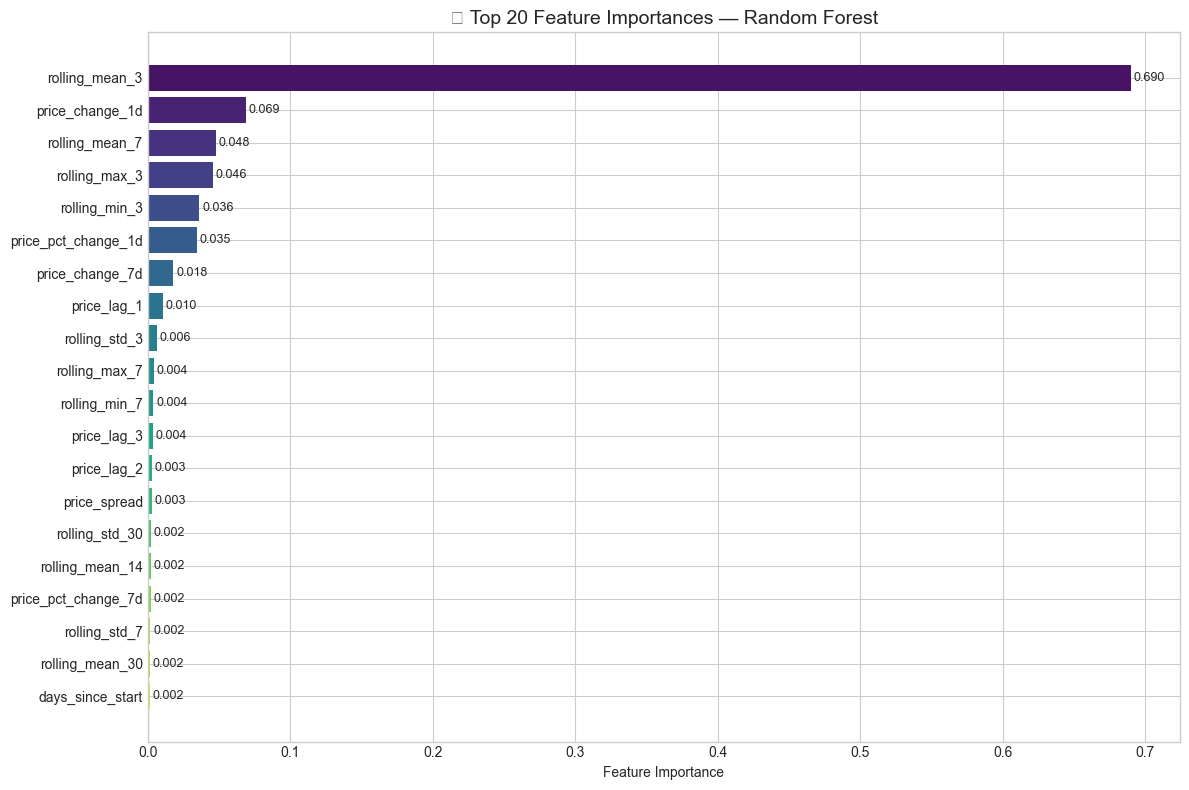


📊 Top 10 Most Important Features:


,feature,importance
0,rolling_mean_3,0.689954
1,price_change_1d,0.069135
2,rolling_mean_7,0.047749
3,rolling_max_3,0.045898
4,rolling_min_3,0.036345
5,price_pct_change_1d,0.034587
6,price_change_7d,0.018139
7,price_lag_1,0.010453
8,rolling_std_3,0.006446
9,rolling_max_7,0.004197


In [11]:
# Feature importance
importances = best_rf.feature_importances_
feature_imp = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot top 20 features
fig, ax = plt.subplots(figsize=(12, 8))
top_n = min(20, len(feature_imp))
top_features = feature_imp.head(top_n)

bars = ax.barh(range(top_n), top_features['importance'].values, color=sns.color_palette("viridis", top_n))
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_features['feature'].values)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance')
ax.set_title('🌲 Top 20 Feature Importances — Random Forest', fontsize=14)

# Add value labels
for i, (val, name) in enumerate(zip(top_features['importance'], top_features['feature'])):
    ax.text(val + 0.002, i, f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Print top 10 as table
print("\n📊 Top 10 Most Important Features:")
display(feature_imp.head(10).reset_index(drop=True))

## Step 11: Visualize Predictions vs Actual Prices

Let's see how well the model predictions match actual prices.

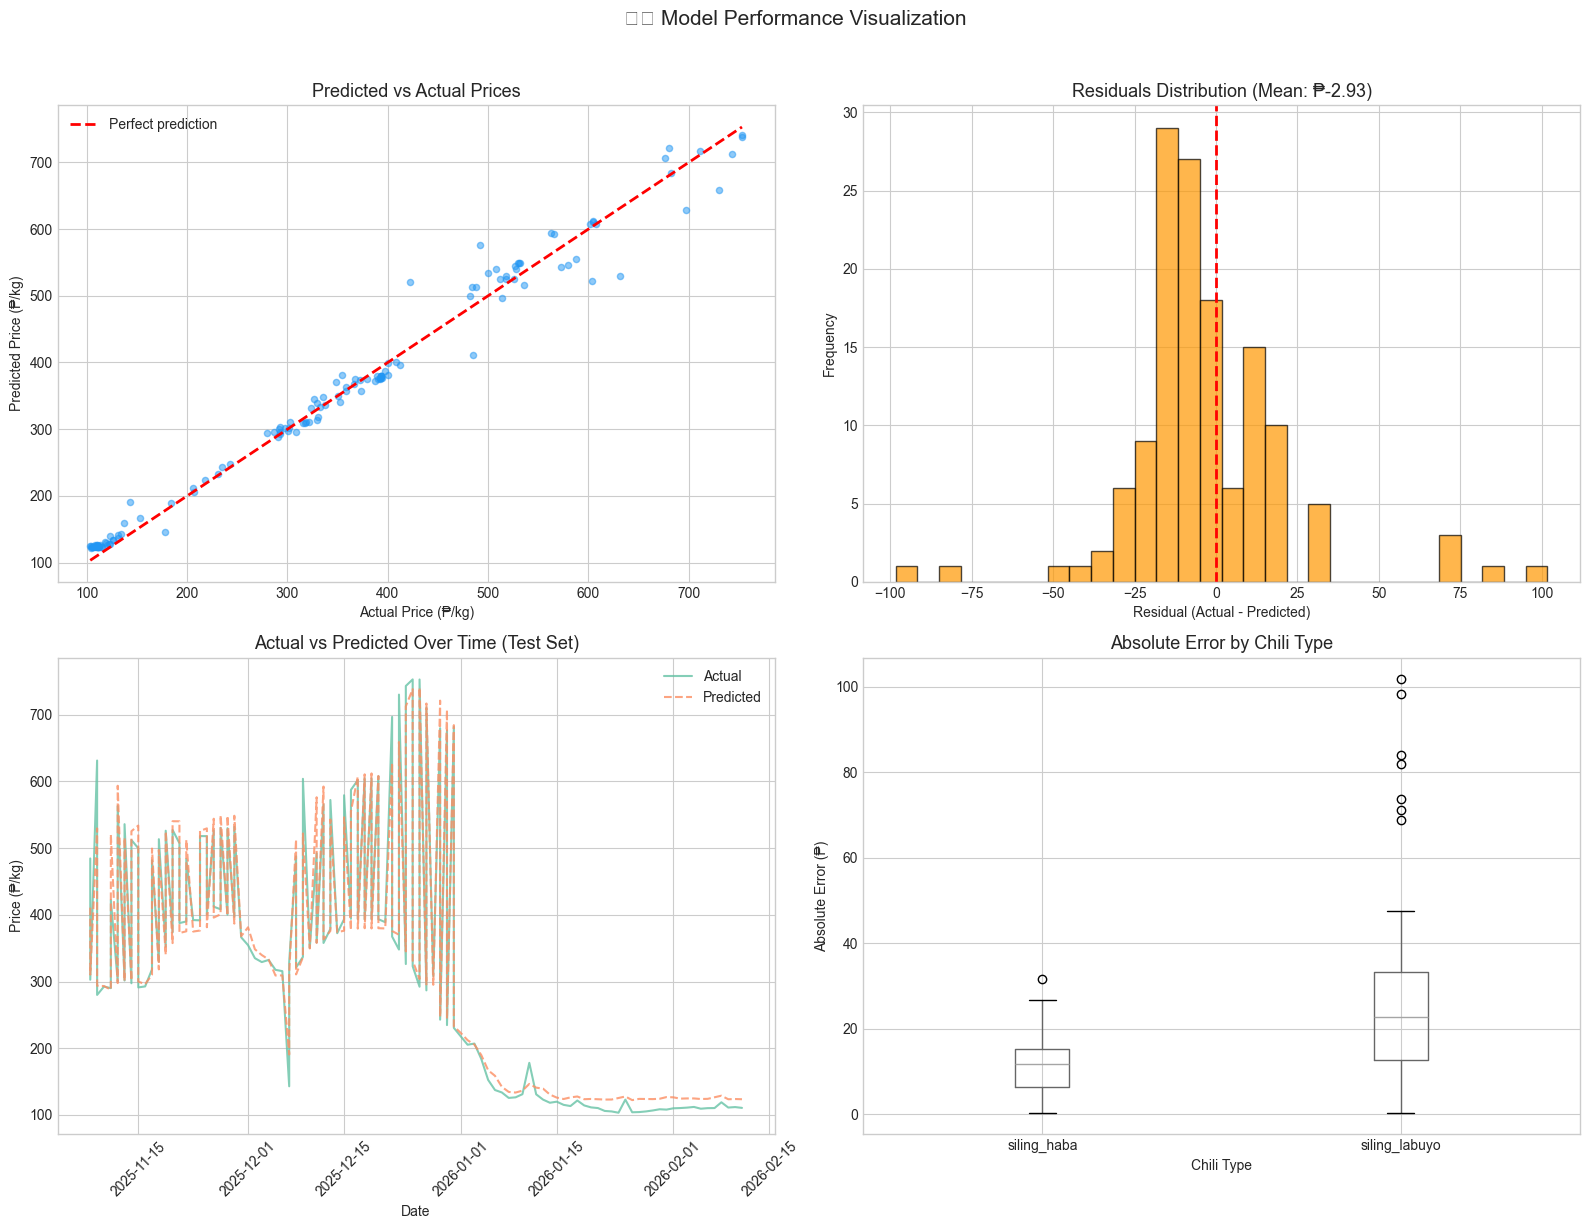

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Scatter plot: Predicted vs Actual
axes[0, 0].scatter(y_test, y_pred_test_best, alpha=0.5, s=20, color='#2196F3')
min_val = min(y_test.min(), y_pred_test_best.min())
max_val = max(y_test.max(), y_pred_test_best.max())
axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
axes[0, 0].set_xlabel('Actual Price (₱/kg)')
axes[0, 0].set_ylabel('Predicted Price (₱/kg)')
axes[0, 0].set_title('Predicted vs Actual Prices', fontsize=13)
axes[0, 0].legend()

# 2. Residuals distribution
residuals = y_test - y_pred_test_best
axes[0, 1].hist(residuals, bins=30, color='#FF9800', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Residual (Actual - Predicted)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Residuals Distribution (Mean: ₱{residuals.mean():.2f})', fontsize=13)

# 3. Time series: Actual vs Predicted
axes[1, 0].plot(dates_test, y_test, label='Actual', alpha=0.8, linewidth=1.5)
axes[1, 0].plot(dates_test, y_pred_test_best, label='Predicted', alpha=0.8, linewidth=1.5, linestyle='--')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Price (₱/kg)')
axes[1, 0].set_title('Actual vs Predicted Over Time (Test Set)', fontsize=13)
axes[1, 0].legend()
axes[1, 0].tick_params(axis='x', rotation=45)

# 4. Error by chili type
error_df = pd.DataFrame({
    'chili_type': types_test,
    'abs_error': np.abs(residuals),
})
error_df.boxplot(column='abs_error', by='chili_type', ax=axes[1, 1])
axes[1, 1].set_title('Absolute Error by Chili Type', fontsize=13)
axes[1, 1].set_xlabel('Chili Type')
axes[1, 1].set_ylabel('Absolute Error (₱)')

plt.suptitle('🌶️ Model Performance Visualization', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Step 12: Save the Trained Model and Metadata

Save everything needed to make predictions in production:
1. The trained Random Forest model (`.joblib`)
2. The feature column names
3. The chili type encoder
4. Model metadata (metrics, training info)

In [13]:
import json

# --- Save model artifacts ---
model_path = os.path.join(MODEL_DIR, "price_rf_model.joblib")
encoder_path = os.path.join(MODEL_DIR, "chili_type_encoder.joblib")
metadata_path = os.path.join(MODEL_DIR, "price_model_metadata.json")

# 1. Save the trained model
joblib.dump(best_rf, model_path)
print(f"✅ Model saved: {model_path}")

# 2. Save the label encoder
joblib.dump(chili_encoder, encoder_path)
print(f"✅ Encoder saved: {encoder_path}")

# 3. Save metadata
metadata = {
    "model_type": "RandomForestRegressor",
    "best_params": grid_search.best_params_,
    "feature_columns": FEATURE_COLS,
    "target_column": TARGET_COL,
    "chili_types": list(chili_encoder.classes_),
    "training_samples": int(X_train.shape[0]),
    "test_samples": int(X_test.shape[0]),
    "metrics": {
        "test_mae": float(mean_absolute_error(y_test, y_pred_test_best)),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_pred_test_best))),
        "test_r2": float(r2_score(y_test, y_pred_test_best)),
        "train_r2": float(r2_score(y_train, y_pred_train_best)),
    },
    "trained_at": datetime.now().isoformat(),
    "data_sources": [
        "Siling Labuyo Price(3).xlsx",
        "Siling Haba.xlsx",
    ],
}

with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"✅ Metadata saved: {metadata_path}")

# 4. Verify loading works
loaded_model = joblib.load(model_path)
test_pred = loaded_model.predict(X_test[:1])
print(f"\n🧪 Verification — sample prediction: ₱{test_pred[0]:.2f}")
print(f"   (actual: ₱{y_test[0]:.2f})")
print(f"\n🎉 All artifacts saved to: {MODEL_DIR}")

✅ Model saved: c:\Users\DELL\Desktop\chili\backend\app\ml\models\price_rf_model.joblib
✅ Encoder saved: c:\Users\DELL\Desktop\chili\backend\app\ml\models\chili_type_encoder.joblib
✅ Metadata saved: c:\Users\DELL\Desktop\chili\backend\app\ml\models\price_model_metadata.json

🧪 Verification — sample prediction: ₱410.82
   (actual: ₱484.61)

🎉 All artifacts saved to: c:\Users\DELL\Desktop\chili\backend\app\ml\models


## Step 13: Save Recent Price History for the Prediction Service

The prediction API needs recent prices (for lag/rolling features). Let's save the last 30 days of data for each chili type.

In [14]:
# Save the most recent price history (needed for lag features at prediction time)
history_path = os.path.join(MODEL_DIR, "price_history.csv")

# Get last 60 rows per chili type (enough for 30-day lags + rolling windows)
history_frames = []
for ctype in df['chili_type'].unique():
    subset = df[df['chili_type'] == ctype].sort_values('date').tail(60)
    history_frames.append(subset)

df_history = pd.concat(history_frames, ignore_index=True)
df_history.to_csv(history_path, index=False)
print(f"✅ Price history saved: {history_path}")
print(f"   Records per type:")
for ctype in df_history['chili_type'].unique():
    n = len(df_history[df_history['chili_type'] == ctype])
    latest = df_history[df_history['chili_type'] == ctype]['date'].max()
    print(f"   • {ctype}: {n} records (latest: {latest.date()})")

print("\n" + "="*60)
print("🎉 TRAINING COMPLETE!")
print("="*60)
print(f"\nFiles saved in {MODEL_DIR}:")
for f in os.listdir(MODEL_DIR):
    size = os.path.getsize(os.path.join(MODEL_DIR, f))
    print(f"  📄 {f} ({size/1024:.1f} KB)")

✅ Price history saved: c:\Users\DELL\Desktop\chili\backend\app\ml\models\price_history.csv
   Records per type:
   • siling_labuyo: 60 records (latest: 2025-12-31)
   • siling_haba: 60 records (latest: 2026-02-11)

🎉 TRAINING COMPLETE!

Files saved in c:\Users\DELL\Desktop\chili\backend\app\ml\models:
  📄 chili_type_encoder.joblib (0.5 KB)
  📄 price_history.csv (4.9 KB)
  📄 price_model_metadata.json (1.5 KB)
  📄 price_rf_model.joblib (2812.0 KB)
